# Credit Card Fraud Detection Using Autoencoder-Based Anomaly Detection
## Phase 1: Data Exploration

This notebook explores the ULB Credit Card Fraud dataset, analyzes its properties, and creates a reproducible subset for modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

Matplotlib is building the font cache; this may take a moment.


### 2. Dataset Loading
We load the dataset from `data/creditcard.csv`.

In [2]:
df = pd.read_csv('../data/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### 3. Dataset Dimensions

In [3]:
print(f'Dataset Shape: {df.shape}')
print(f'Total Rows: {df.shape[0]}')
print(f'Total Columns: {df.shape[1]}')

Dataset Shape: (284807, 31)
Total Rows: 284807
Total Columns: 31


### 4. Column Inspection

In [4]:
print(df.columns.tolist())

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


### 5. Data Types

In [5]:
print(df.dtypes)

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


### 6. Missing-Value Analysis

In [6]:
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])
print('Total missing values:', missing_values.sum())

Series([], dtype: int64)
Total missing values: 0


### 7. Duplicate Analysis

In [7]:
duplicates = df.duplicated().sum()
print(f'Total duplicate rows: {duplicates}')
# Keeping duplicates for now as they could be valid transactions at the exact same time with the exact same amount/features

Total duplicate rows: 1081


### 8. Full Dataset Class Distribution

In [8]:
class_counts = df['Class'].value_counts()
print(class_counts)
print(f"Fraud Percentage: {class_counts[1] / len(df) * 100:.3f}%")

Class
0    284315
1       492
Name: count, dtype: int64
Fraud Percentage: 0.173%


### 9. Subset Construction
We need a reproducible subset of approximately 30,000-31,000 transactions containing ALL 492 fraudulent transactions and a random sample of legitimate transactions. We will sample 30,000 legitimate transactions using a fixed random seed.

In [9]:
# Set fixed random seed for reproducibility
np.random.seed(42)

# Separate fraud and legitimate
fraud_df = df[df['Class'] == 1]
legit_df = df[df['Class'] == 0]

# Sample legitimate transactions
target_legit_count = 30000
sampled_legit_df = legit_df.sample(n=target_legit_count, random_state=42)

# Combine and shuffle
subset_df = pd.concat([fraud_df, sampled_legit_df]).sample(frac=1, random_state=42).reset_index(drop=True)

# Save subset (optional, but good for reproducibility downstream if we want to read it directly)
# For now, we will just use subset_df in the rest of the notebook.
# Actually, let's write it to data/subset_creditcard.csv
subset_df.to_csv('../data/subset_creditcard.csv', index=False)
print("Subset constructed and saved to data/subset_creditcard.csv")

Subset constructed and saved to data/subset_creditcard.csv


### 10. Subset Class Distribution

In [10]:
subset_class_counts = subset_df['Class'].value_counts()
print(subset_class_counts)

Class
0    30000
1      492
Name: count, dtype: int64


### 11. Subset Fraud Percentage

In [11]:
subset_fraud_pct = subset_class_counts[1] / len(subset_df) * 100
print(f"Subset Fraud Percentage: {subset_fraud_pct:.3f}%")

Subset Fraud Percentage: 1.614%


### 12. Transaction Amount Statistics

In [12]:
print(subset_df['Amount'].describe())

count    30492.000000
mean        87.603202
std        228.119612
min          0.000000
25%          5.380000
50%         21.820000
75%         76.830000
max       8360.000000
Name: Amount, dtype: float64


### 13. Time Statistics

In [13]:
print(subset_df['Time'].describe())

count     30492.000000
mean      94664.296734
std       47508.663799
min           0.000000
25%       54229.750000
50%       84625.000000
75%      139135.750000
max      172768.000000
Name: Time, dtype: float64


### 14. Fraud vs Legitimate Amount Comparison

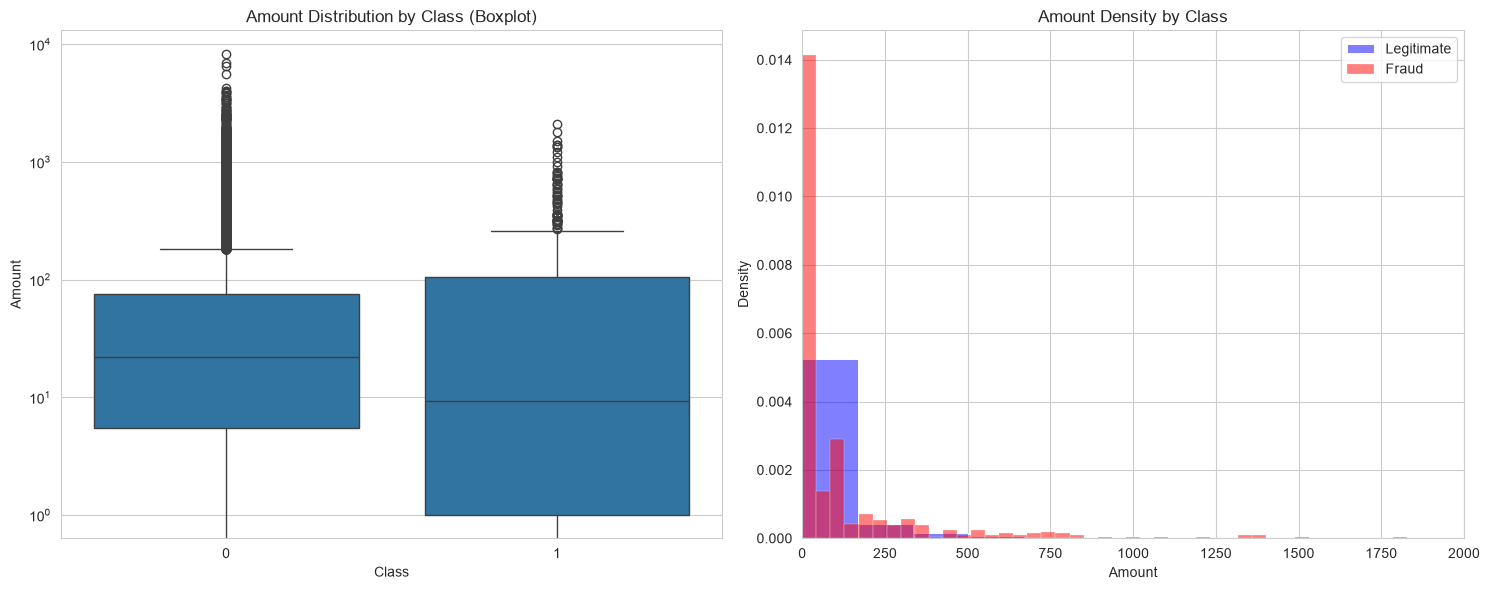

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(x='Class', y='Amount', data=subset_df, ax=axes[0])
axes[0].set_title('Amount Distribution by Class (Boxplot)')
axes[0].set_yscale('log') # Log scale is useful because amounts vary widely

sns.histplot(subset_df[subset_df['Class'] == 0]['Amount'], bins=50, color='blue', alpha=0.5, label='Legitimate', stat='density', ax=axes[1])
sns.histplot(subset_df[subset_df['Class'] == 1]['Amount'], bins=50, color='red', alpha=0.5, label='Fraud', stat='density', ax=axes[1])
axes[1].set_title('Amount Density by Class')
axes[1].set_xlim(0, 2000)
axes[1].legend()

plt.tight_layout()
plt.show()

### 15. Fraud vs Legitimate Time Analysis

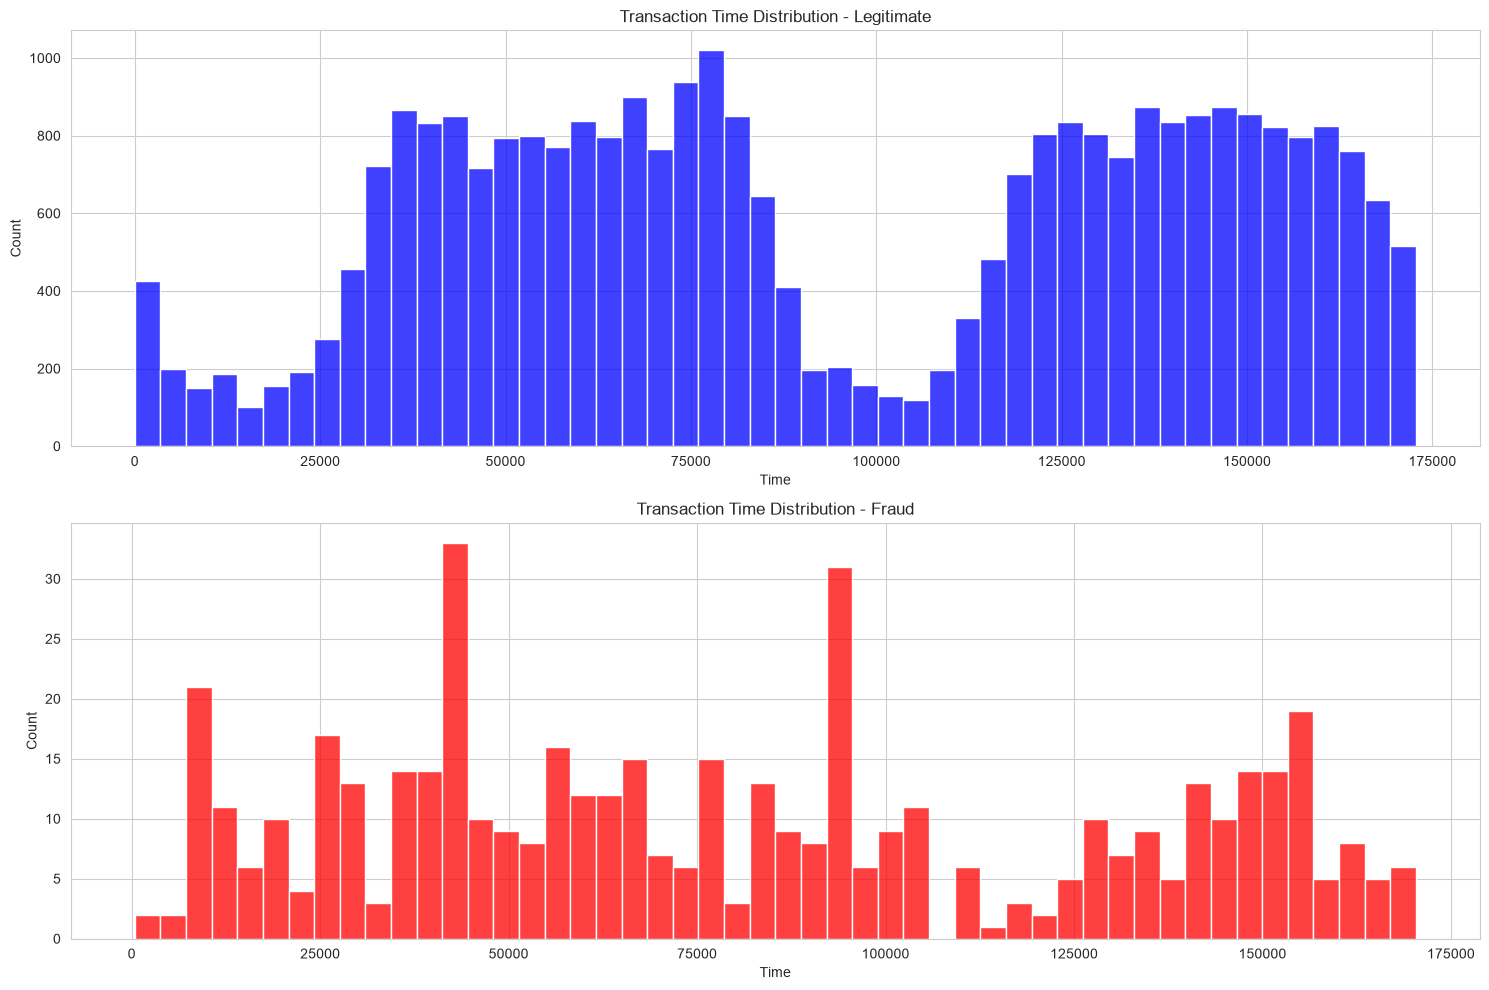

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

sns.histplot(subset_df[subset_df['Class'] == 0]['Time'], bins=50, color='blue', label='Legitimate', ax=axes[0])
axes[0].set_title('Transaction Time Distribution - Legitimate')

sns.histplot(subset_df[subset_df['Class'] == 1]['Time'], bins=50, color='red', label='Fraud', ax=axes[1])
axes[1].set_title('Transaction Time Distribution - Fraud')

plt.tight_layout()
plt.show()

### 16. Feature Distributions (V1-V28)

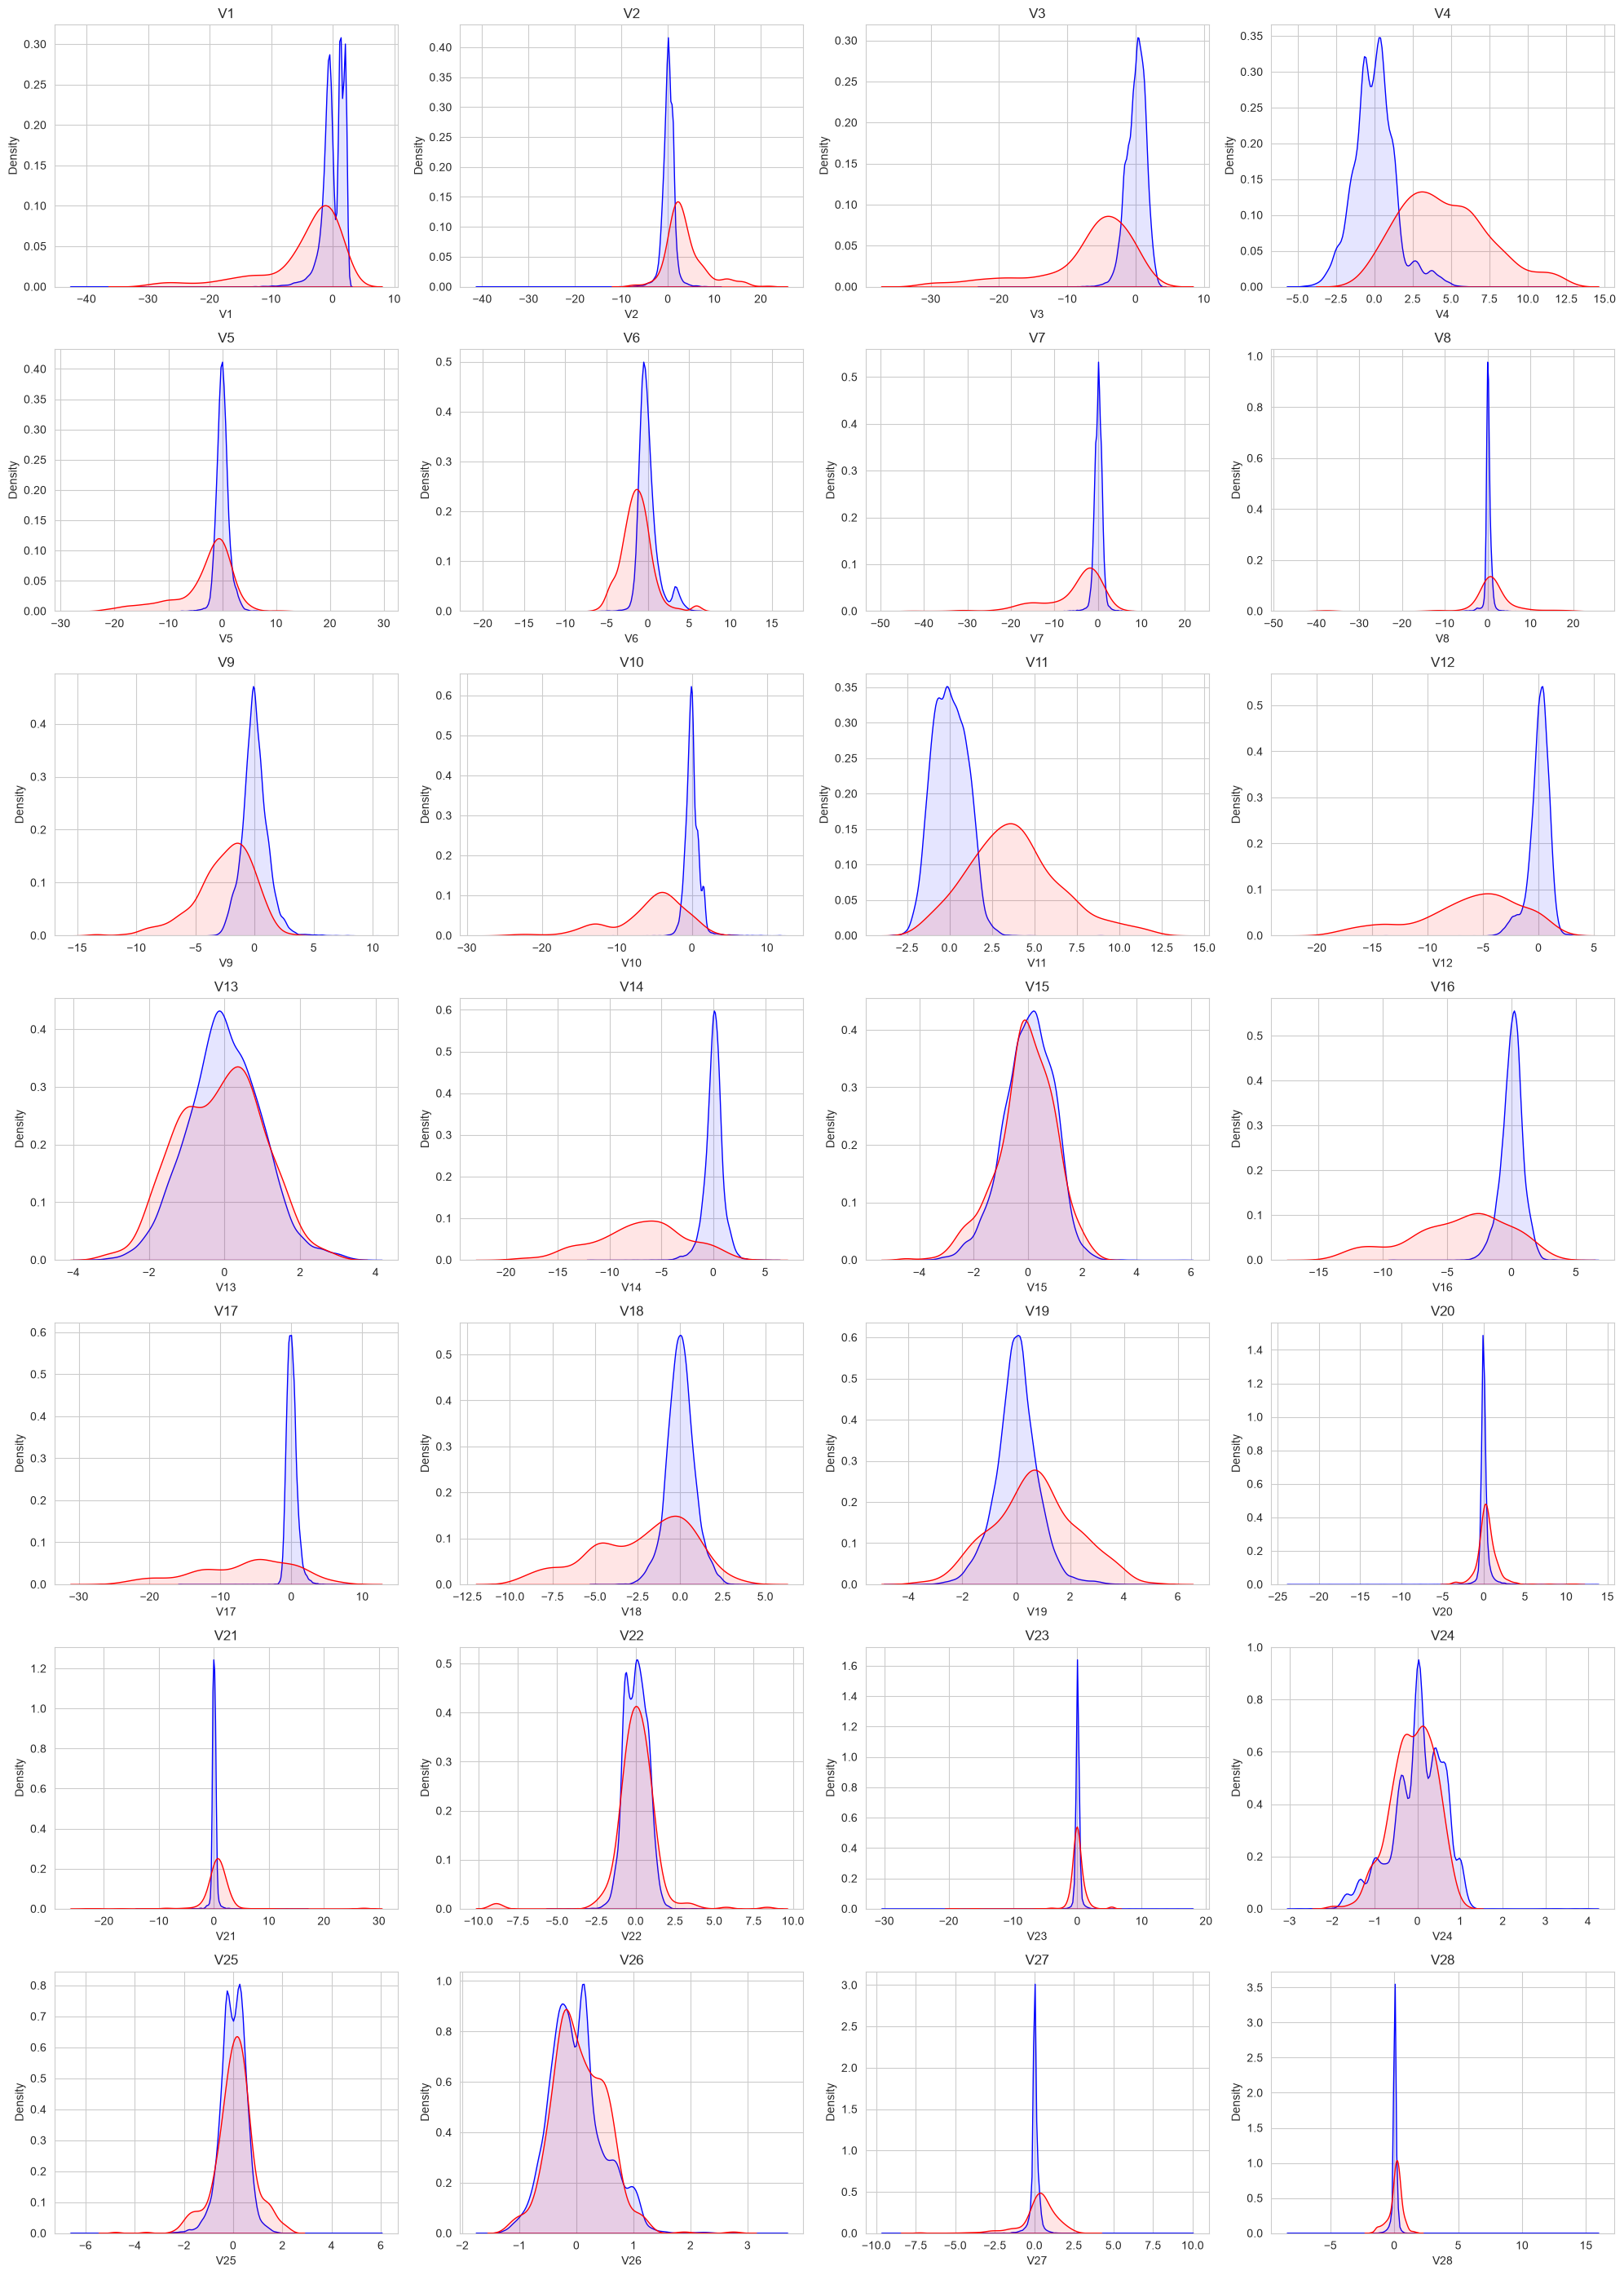

In [16]:
v_features = subset_df.columns[1:29] # V1 to V28
plt.figure(figsize=(20, 28))
for i, feature in enumerate(v_features):
    plt.subplot(7, 4, i+1)
    sns.kdeplot(subset_df[subset_df['Class'] == 0][feature], color='blue', label='Legitimate', fill=True, alpha=0.1)
    sns.kdeplot(subset_df[subset_df['Class'] == 1][feature], color='red', label='Fraud', fill=True, alpha=0.1)
    plt.title(feature)
plt.tight_layout()
plt.show()

### 17. Correlation Analysis

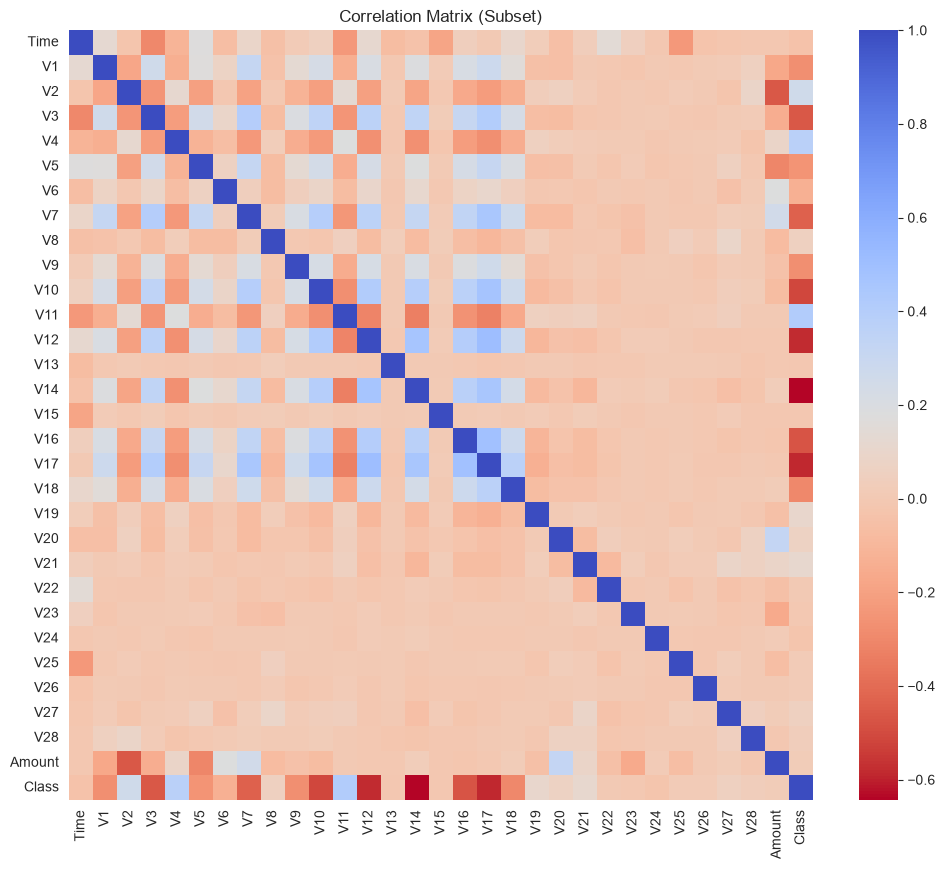

In [17]:
corr = subset_df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm_r', annot_kws={'size':10})
plt.title('Correlation Matrix (Subset)')
plt.show()

### 18. Useful Visualizations: Pairplot on highly correlated features
Let's pick a few features that showed strong correlation with the Class (positive or negative) and plot them.

Top negative correlations with Class:
V14   -0.644051
V17   -0.588982
V12   -0.582407
Name: Class, dtype: float64

Top positive correlations with Class:
V2     0.259058
V4     0.371150
V11    0.415258
Name: Class, dtype: float64


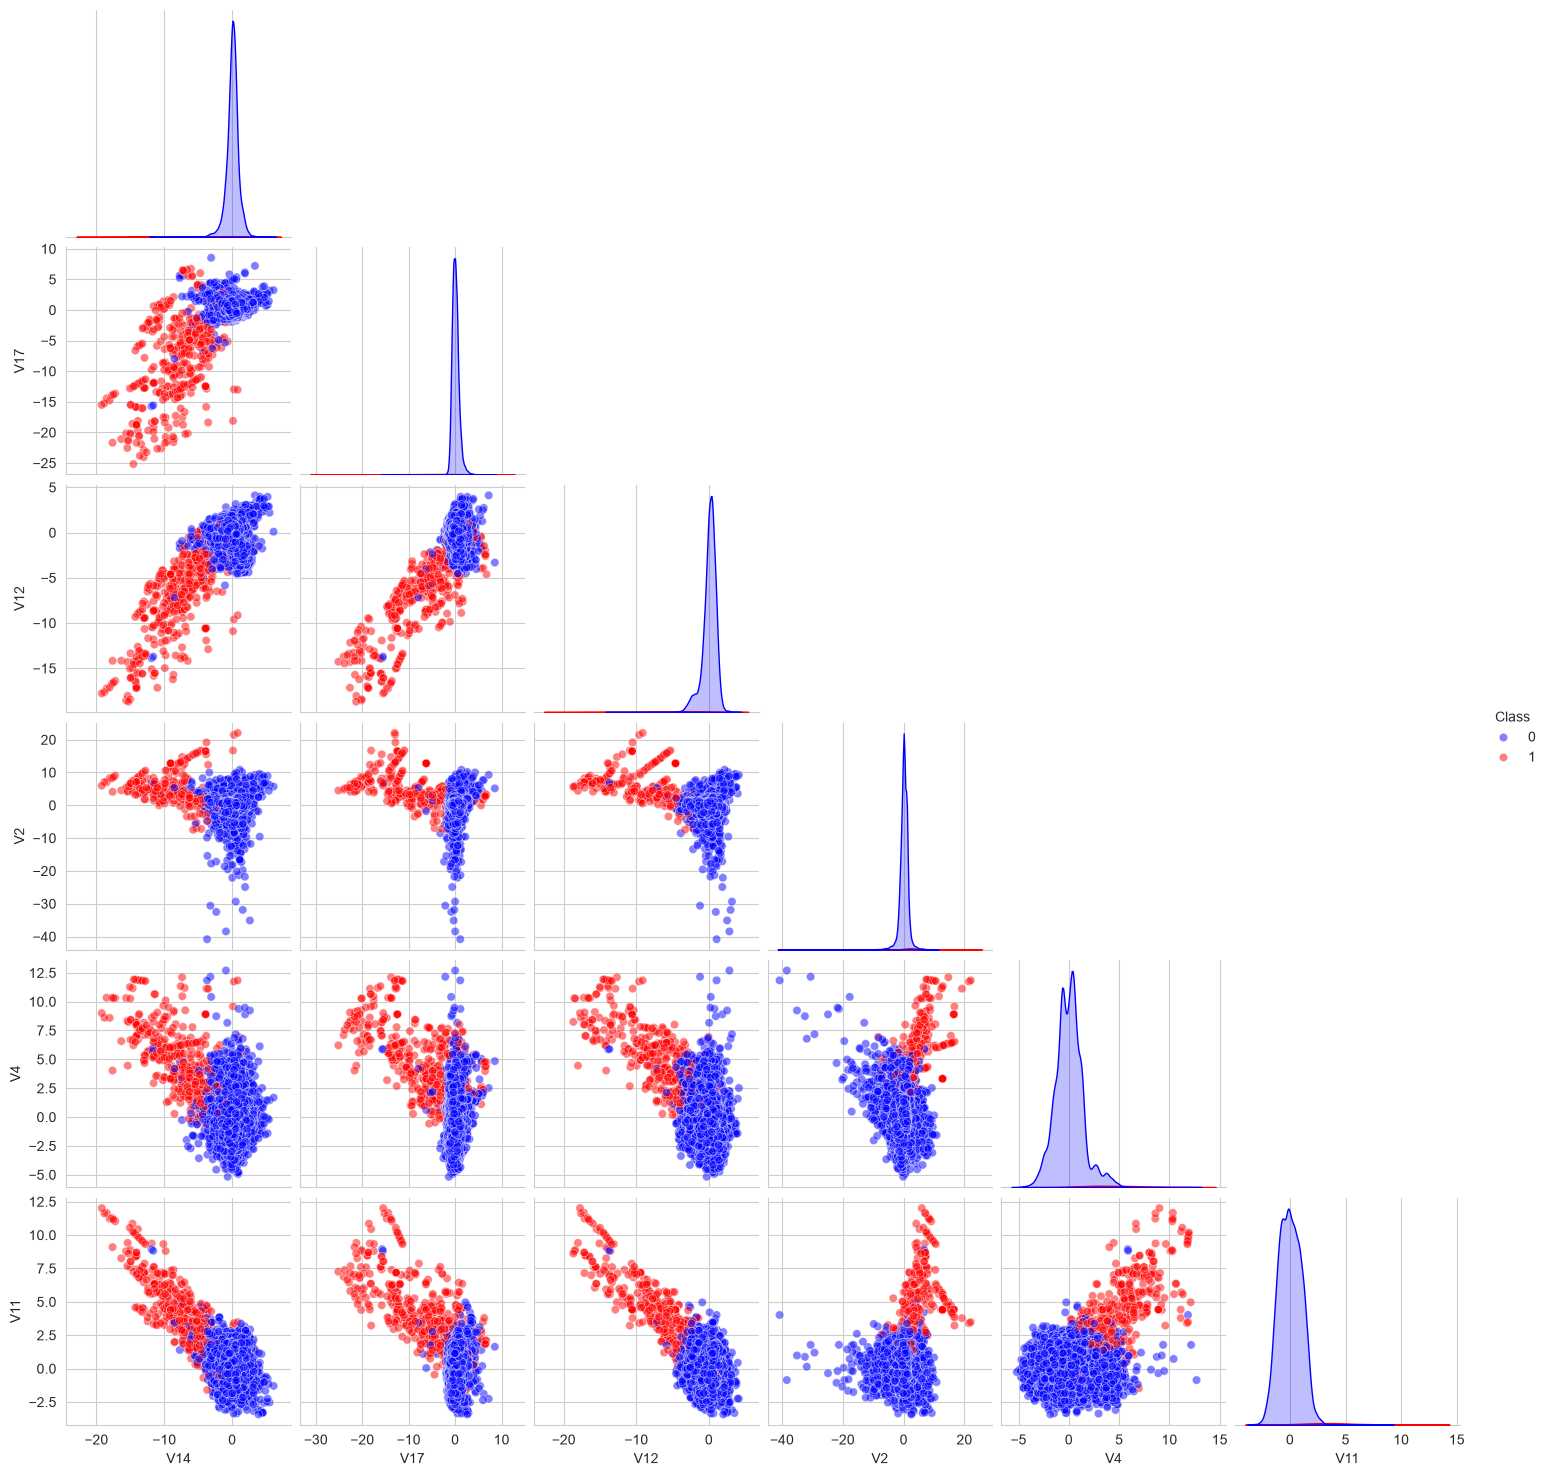

In [18]:
# Features most correlated with Class
corr_with_class = corr['Class'].drop('Class').sort_values()
print("Top negative correlations with Class:")
print(corr_with_class.head(3))
print("\nTop positive correlations with Class:")
print(corr_with_class.tail(3))

top_features = corr_with_class.head(3).index.tolist() + corr_with_class.tail(3).index.tolist() + ['Class']
sns.pairplot(subset_df[top_features], hue='Class', diag_kind='kde', corner=True, palette={0: 'blue', 1: 'red'}, plot_kws={'alpha': 0.5})
plt.show()

### 19. Key Observations

1. **Data Imbalance**: The original dataset is extremely imbalanced (~0.17% fraud). Our subset is ~1.6% fraud, making experimentation faster while preserving all fraud cases.
2. **Missing Values & Duplicates**: There are no missing values. There are some duplicates (which we kept as they could be legitimate concurrent transactions).
3. **Time Feature**: Fraud transactions do not clearly follow the same cyclical Time distribution as legitimate transactions.
4. **Amount Feature**: Fraudulent transactions tend to have smaller amounts, although there are outliers. Legitimate transactions have a much longer tail in the Amount distribution.
5. **V Features**: V1-V28 are PCA features. Features like V14, V12, V10 show very distinct distributions for fraud vs. legitimate transactions, and they have strong negative correlations with the Class variable, indicating they will be useful for the autoencoder to distinguish normality from anomaly.
6. **Correlations**: Since V1-V28 are PCA transformed, they have close to zero correlation with each other in the *full* dataset. In our subset, some small correlations might appear due to sampling, but they remain largely independent. Strong correlations exist between some V features and the Class label.